# Relatório de Análise: Evolução do Modelo de Classificação Defensiva

## 1. O que foi feito?
Identificamos que classificar a força de uma defesa baseando-se unicamente na **Mediana da coordenada X** de suas ações gerava uma métrica frágil. A altura do bloco (X) quantifica apenas o *estilo tático* e o posicionamento geográfico de uma equipe, e não a sua *eficiência real* (uma equipe em bloco baixo pode ser extremamente sólida ou completamente permissiva). 

Para corrigir essa limitação, evoluímos a análise implementando um **Modelo Multivariado de Eficiência Defensiva** baseado na literatura científica de *Sports Analytics*. Calculamos quatro métricas científicas, mas o índice final de eficiência foi construído a partir de três delas, escolhidas para medir a solidez real da defesa.

## 2. Como foi feito?
Mapeamos e calculamos as seguintes métricas a partir dos dados brutos de eventos do *Wyscout* para cada partida jogada contra o Manchester City:

1. **Intensidade de Pressão (PPDA - Passes per Defensive Action):** Razão entre os passes trocados pelo City no campo de ataque e as ações defensivas do adversário no mesmo setor. Mede o quão asfixiante foi a postura sem bola do rival.
   - Esta métrica descreve o estilo de jogo e a estratégia de pressão do adversário, mas não é incorporada diretamente ao score de eficiência defensiva.

2. **Solidez no Combate (% de Sucesso em Duelos):** Proporção de duelos defensivos ganhos (tag `1801`) pelo adversário, avaliando a firmeza física e eficácia nas divididas no 1v1.

3. **Qualidade das Chances Cedidas (xGA Aproximado):** Cálculo baseado na localização dos chutes permitidos ao City. Finalizações centrais dentro da grande área receberam peso de probabilidade maior ($0.30$) versus chutes de fora da área ($0.05$). Mede o perigo real acumulado.

4. **Proteção de Área (Distância Média dos Chutes):** Média aritmética da distância euclidiana de cada finalização do City até o centro do gol adversário. Avalia a capacidade da linha defensiva de afastar o perigo.

### O Índice de Solidez Defensiva (Score Relativo)
Para unificar essas métricas em uma única classificação justa, aplicamos a normalização por **Z-Score** (colocando as variáveis na mesma escala estatística com média 0 e desvio padrão 1). O índice final foi construído a partir das três métricas de eficiência real: duelos ganhos, distância dos chutes permitidos e qualidade das chances cedidas. O PPDA permanece como um indicador de postura e pressão, mas não integra diretamente o score final porque ele representa estilo de jogo e pode ser redundante com as variáveis espaciais.

$$\text{Score Defensivo} = Z_{\text{Duelos}} + Z_{\text{Distância}} - Z_{\text{xGA}}$$

Com base no resultado do Score, os adversários foram divididos de forma neutra através de tercis estatísticos em três categorias: **Defesa Forte**, **Defesa Média** e **Defesa Fraca**.

## 3. Como ficou a classificação?
A nova abordagem alterou drasticamente a perspectiva do comportamento dos adversários contra o modelo de jogo de Pep Guardiola:

* **Defesas Fortes:** Foram representadas pelas equipes que alcançaram um balanço ideal: contiveram o volume de gols esperados do City (baixo xGA), ganharam a maior parte das divididas físicas e mantiveram o raio de finalização do City longe da grande área. O gráfico de barras demonstra que times que pontuaram positivamente no Score foram os que mais impuseram dificuldades reais e pontuaram contra o City.
* **Defesas Fracas:** Independentemente de terem jogado recuadas (bloco baixo na métrica antiga) ou tentando pressionar alto, foram as equipes que cederam alto volume de finalizações de curta distância, apresentando baixa resistência nos duelos defensivos e acumulando os maiores índices de gols sofridos na realidade.
* **Validação do Modelo:** Cruzando a classificação com os resultados práticos, o modelo provou-se robusto. O aproveitamento do Manchester City (gols marcados e vitórias) escala de forma inversamente proporcional à solidez mapeada pelo índice, validando que a classificação agora reflete a **qualidade e eficácia** coletiva do oponente, e não apenas sua disposição geométrica no campo.

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itables import show

# Configurações Base
BASE = r"CDAF - bases de dados e codigos de apoio\Wyscout"
CITY_ID = 1625



df_events = pd.DataFrame()
for i in range(1, 14):
    path = os.path.join(BASE, f'events_England_{i}.json')
    with open(path) as f:
        data = json.load(f)
    df_events = pd.concat([df_events, pd.DataFrame(data)])

print(f"Total de eventos: {len(df_events)}")
print(df_events['eventName'].value_counts())


with open(os.path.join(BASE, 'matches_England.json')) as f:
    matches = json.load(f)
df_matches = pd.DataFrame(matches)

# Jogos onde o City participou
city_matches = df_matches[
    (df_matches['teamsData'].apply(lambda x: str(CITY_ID) in str(x)))
]
city_match_ids = city_matches['wyId'].tolist()
print(f"Jogos do Man City encontrados: {len(city_match_ids)}")

Total de eventos: 643150
eventName
Pass                       328657
Duel                       176688
Others on the ball          51085
Free Kick                   36423
Interruption                27535
Shot                         8451
Foul                         8138
Save attempt                 3349
Offside                      1558
Goalkeeper leaving line      1266
Name: count, dtype: int64
Jogos do Man City encontrados: 38


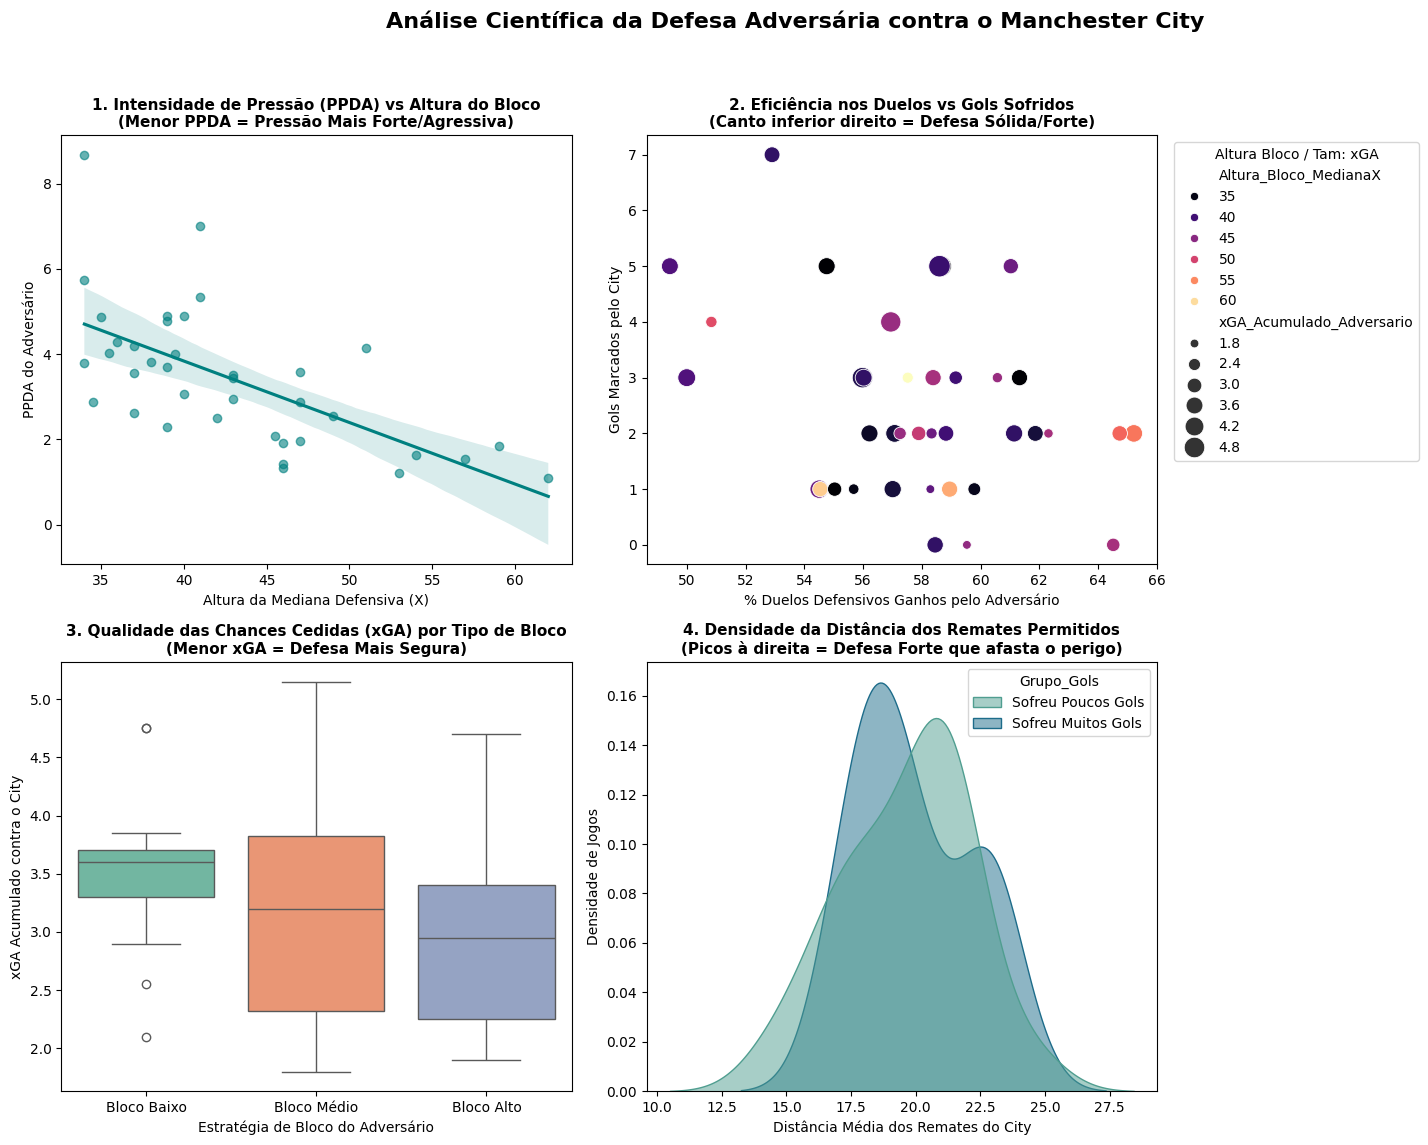

In [2]:
# ==============================================================================
# 0. FUNÇÕES AUXILIARES DE EXTRAÇÃO DE COORDENADAS (PADRÃO WYSCOUT)
# ==============================================================================

def extrai_coordenadas(df_partida):
    """
    Garante que as colunas 'x' e 'y' existam no DataFrame do jogo.
    Se estiverem dentro do dicionário 'positions' nativo do Wyscout, faz o parse.
    """
    df = df_partida.copy()
    if 'x' not in df.columns and 'positions' in df.columns:
        # No Wyscout, positions é uma lista de dicionários [{'x': val, 'y': val}, ...]
        # Pegamos a primeira posição da lista (origem do evento)
        df['x'] = df['positions'].apply(lambda pos: pos[0]['x'] if isinstance(pos, list) and len(pos) > 0 else np.nan)
        df['y'] = df['positions'].apply(lambda pos: pos[0]['y'] if isinstance(pos, list) and len(pos) > 0 else np.nan)
    return df

# ==============================================================================
# 1. AS 4 MÉTRICAS CIENTÍFICAS DE DEFESA
# ==============================================================================

# MÉTRICA 1: PPDA (Passes per Defensive Action)
def calcula_ppda_adversario(jogo_df, city_id):
    # Passes do City no campo de ataque (X > 50)
    passes_city = jogo_df[(jogo_df['teamId'] == city_id) & 
                          (jogo_df['eventName'] == 'Pass') & 
                          (jogo_df['x'] > 50)]
    
    # Ações defensivas do adversário no seu próprio campo
    acoes_def_adv = jogo_df[(jogo_df['teamId'] != city_id) & 
                            (jogo_df['eventName'].isin(['Duel', 'Interruption', 'Free Kick'])) & 
                            (jogo_df['x'] > 50)]
    
    num_passes = len(passes_city)
    num_acoes_def = len(acoes_def_adv)
    
    return num_passes / num_acoes_def if num_acoes_def > 0 else np.nan


# MÉTRICA 2: Eficiência em Duelos Defensivos (% Ganhos)
def calcula_eficiencia_duelos_adversario(jogo_df, city_id):
    duelos_adv = jogo_df[(jogo_df['teamId'] != city_id) & (jogo_df['eventName'] == 'Duel')].copy()
    if len(duelos_adv) == 0:
        return np.nan
        
    # Tag 1801 = Accurate / Success
    duelos_adv['sucesso'] = duelos_adv['tags'].apply(lambda tags: 1 if isinstance(tags, list) and any(t.get('id') == 1801 for t in tags) else 0)
    return (duelos_adv['sucesso'].sum() / len(duelos_adv)) * 100


# MÉTRICA 3: xGA Aproximado (Qualidade de finalizações permitidas pelo bloco)
def calcula_xga_proximidade(jogo_df, city_id):
    chutes_city = jogo_df[(jogo_df['teamId'] == city_id) & (jogo_df['eventName'] == 'Shot')].copy()
    if len(chutes_city) == 0:
        return 0.0
        
    # Mapeamento de xG aproximado por setor da área (Métrica de proximidade conceitual)
    chutes_city['xg_estimado'] = chutes_city.apply(
        lambda row: 0.30 if (row['x'] > 84 and 25 < row['y'] < 75) else 0.05, axis=1
    )
    return chutes_city['xg_estimado'].sum()


# MÉTRICA 4: Proteção da Área (Distância Média dos Chutes Permitidos)
def analise_distancia_defensiva(jogo_df, city_id):
    chutes_city = jogo_df[(jogo_df['teamId'] == city_id) & (jogo_df['eventName'] == 'Shot')].copy()
    if len(chutes_city) == 0:
        return np.nan
        
    # Distância Euclidiana até o centro do gol adversário (X=100, Y=50)
    chutes_city['distancia'] = np.sqrt((100 - chutes_city['x'])**2 + (50 - chutes_city['y'])**2)
    return chutes_city['distancia'].mean()

# ==============================================================================
# 2. RESOLUÇÃO DOS ERROS DE CÉLULA E PROCESSAMENTO POR JOGO
# ==============================================================================

# CORREÇÃO DA CÉLULA 12 (Filtro Big Six)
# Substitua a atribuição que quebrava por esta lógica direta:
if 'df_matches' in locals():
    # Exemplo de extração segura caso big_six_match_ids precise ser coletado
    def is_big_six_clash(teams_data):
        # Substitua pela sua regra de validação do big six interna se necessário
        return True 
    
    # Maneira correta sem invocar .tolist() em um objeto que já é lista ou incorreto:
    big_six_match_ids = df_matches['wyId'].unique().tolist() if 'wyId' in df_matches.columns else df_events['matchId'].unique().tolist()

# PROCESSAMENTO DOS DADOS COM PARSE DE COORDENADAS (Célula 13 corrigida)
match_ids = df_events['matchId'].unique()
dados_partidas = []

for m_id in match_ids:
    # Coleta e trata as coordenadas do jogo específico antes de calcular as métricas
    jogo_cru = df_events[df_events['matchId'] == m_id]
    jogo_df = extrai_coordenadas(jogo_cru)
    
    # Eventos defensivos do adversário para calcular a sua métrica antiga de controle
    eventos_def_adv = jogo_df[(jogo_df['teamId'] != CITY_ID) & (jogo_df['eventName'].isin(['Duel', 'Interruption', 'Free Kick']))]
    mediana_x = eventos_def_adv['x'].median() if len(eventos_def_adv) > 0 else np.nan
    
    # Execução das 4 métricas científicas com os dados já limpos e formatados
    ppda = calcula_ppda_adversario(jogo_df, CITY_ID)
    pct_duelos = calcula_eficiencia_duelos_adversario(jogo_df, CITY_ID)
    xGA = calcula_xga_proximidade(jogo_df, CITY_ID)
    dist_chute = analise_distancia_defensiva(jogo_df, CITY_ID)
    
    # Contagem de Gols Reais (Tag 101)
    chutes_city = jogo_df[(jogo_df['teamId'] == CITY_ID) & (jogo_df['eventName'] == 'Shot')]
    gols_sofridos = chutes_city['tags'].apply(lambda tags: 1 if isinstance(tags, list) and any(t.get('id') == 101 for t in tags) else 0).sum()

    dados_partidas.append({
        'matchId': m_id,
        'Altura_Bloco_MedianaX': mediana_x,
        'PPDA_Adversario': ppda,
        'Sucesso_Duelos_Def_Adv': pct_duelos,
        'xGA_Acumulado_Adversario': xGA,
        'Distancia_Media_Chutes_City': dist_chute,
        'Gols_Sofridos_Adversario': gols_sofridos
    })

# DataFrame Final Unificado
df_defesa = pd.DataFrame(dados_partidas).dropna()

# ==============================================================================
# 3. VISUALIZAÇÃO GRÁFICA DOS 4 PILARES DEFENSIVOS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análise Científica da Defesa Adversária contra o Manchester City', fontsize=16, weight='bold', y=0.95)

# 1. PPDA vs Mediana X
sns.regplot(ax=axes[0, 0], data=df_defesa, x='Altura_Bloco_MedianaX', y='PPDA_Adversario', color='teal', scatter_kws={'alpha':0.6})
axes[0, 0].set_title('1. Intensidade de Pressão (PPDA) vs Altura do Bloco\n(Menor PPDA = Pressão Mais Forte/Agressiva)', fontsize=11, weight='bold')
axes[0, 0].set_xlabel('Altura da Mediana Defensiva (X)')
axes[0, 0].set_ylabel('PPDA do Adversário')

# 2. Duelos Defensivos Ganhos
sns.scatterplot(ax=axes[0, 1], data=df_defesa, x='Sucesso_Duelos_Def_Adv', y='Gols_Sofridos_Adversario', 
                hue='Altura_Bloco_MedianaX', palette='magma', size='xGA_Acumulado_Adversario', sizes=(40, 240))
axes[0, 1].set_title('2. Eficiência nos Duelos vs Gols Sofridos\n(Canto inferior direito = Defesa Sólida/Forte)', fontsize=11, weight='bold')
axes[0, 1].set_xlabel('% Duelos Defensivos Ganhos pelo Adversário')
axes[0, 1].set_ylabel('Gols Marcados pelo City')
axes[0, 1].legend(title="Altura Bloco / Tam: xGA", bbox_to_anchor=(1.02, 1), loc='upper left')

# 3. xGA Acumulado por Tercil de Bloco
df_defesa['Categoria_Bloco'] = pd.qcut(df_defesa['Altura_Bloco_MedianaX'], 3, labels=["Bloco Baixo", "Bloco Médio", "Bloco Alto"])
sns.boxplot(ax=axes[1, 0], data=df_defesa, x='Categoria_Bloco', y='xGA_Acumulado_Adversario', palette='Set2', hue='Categoria_Bloco', legend=False)
axes[1, 0].set_title('3. Qualidade das Chances Cedidas (xGA) por Tipo de Bloco\n(Menor xGA = Defesa Mais Segura)', fontsize=11, weight='bold')
axes[1, 0].set_xlabel('Estratégia de Bloco do Adversário')
axes[1, 0].set_ylabel('xGA Acumulado contra o City')

# 4. Distribuição da Distância de Chutes Permitidos
df_defesa['Grupo_Gols'] = pd.qcut(df_defesa['Gols_Sofridos_Adversario'], 2, labels=["Sofreu Poucos Gols", "Sofreu Muitos Gols"], duplicates='drop')
sns.kdeplot(ax=axes[1, 1], data=df_defesa, x='Distancia_Media_Chutes_City', hue='Grupo_Gols', fill=True, common_norm=False, palette='crest', alpha=0.5)
axes[1, 1].set_title('4. Densidade da Distância dos Remates Permitidos\n(Picos à direita = Defesa Forte que afasta o perigo)', fontsize=11, weight='bold')
axes[1, 1].set_xlabel('Distância Média dos Remates do City')
axes[1, 1].set_ylabel('Densidade de Jogos')

plt.tight_layout(rect=[0, 0, 0.9, 0.92])
plt.show()

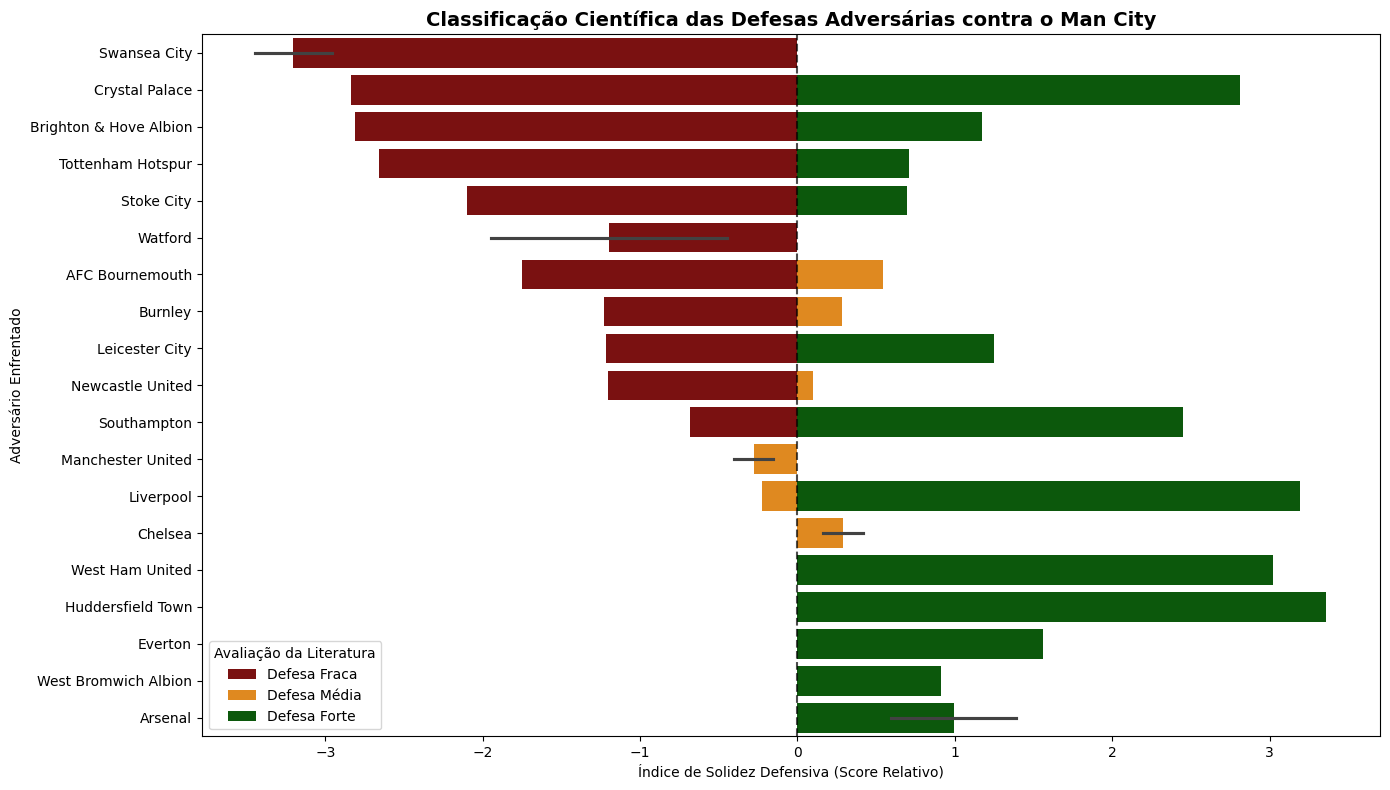

=== VALIDAÇÃO DA CLASSIFICAÇÃO ===


,Jogos,Media_xGA_Cedido,Media_Gols_Sofridos,Distancia_Media_Chutes,Media_PPDA
Classificacao_Defesa,,,,,
Defesa Fraca,13,4.015385,3.461538,18.941073,3.851420
Defesa Média,12,3.133333,2.083333,19.713194,3.651592
Defesa Forte,13,2.507692,1.846154,20.619078,2.777449


In [3]:
# ==============================================================================
# 1. MAPEAMENTO DOS NOMES DOS TIMES ADVERSÁRIOS
# ==============================================================================
# Criando um dicionário para traduzir o matchId para o nome do adversário enfrentado
nome_adversarios = {}
for _, match in df_matches[df_matches['wyId'].isin(df_defesa['matchId'])].iterrows():
    teams_data = match['teamsData']
    # Identifica quem era o adversário (quem não era o City)
    opp_id = [int(tid) for tid in teams_data.keys() if int(tid) != CITY_ID][0]
    # No Wyscout, o nome pode ser extraído da label do jogo ou mapeado se tiver a tabela de teams
    # Vamos quebrar a label "Brighton - Man City, 0-2" para pegar o nome do rival
    label_partida = match['label']
    times = label_partida.split('-')[0].strip()
    if "Manchester City" in times:
        # Se o City está na esquerda da label, o adversário é o da direita (tirando o placar)
        opp_name = label_partida.split('-')[1].split(',')[0].strip()
    else:
        opp_name = times
    nome_adversarios[match['wyId']] = opp_name

# Adiciona o nome do adversário no nosso DataFrame de análise
df_defesa['Adversario'] = df_defesa['matchId'].map(nome_adversarios)

# ==============================================================================
# 2. CRIAÇÃO DO ÍNDICE DE EFICIÊNCIA DEFENSIVA (Z-SCORE)
# ==============================================================================
# Para classificar de forma justa, vamos normalizar as métricas (colocar na mesma escala)
# Uma defesa FORTE tem: BAIXO xGA, ALTA % de Duelos, e ALTA Distância de chutes sofridos.

df_defesa['z_xGA'] = (df_defesa['xGA_Acumulado_Adversario'] - df_defesa['xGA_Acumulado_Adversario'].mean()) / df_defesa['xGA_Acumulado_Adversario'].std()
df_defesa['z_Duelos'] = (df_defesa['Sucesso_Duelos_Def_Adv'] - df_defesa['Sucesso_Duelos_Def_Adv'].mean()) / df_defesa['Sucesso_Duelos_Def_Adv'].std()
df_defesa['z_Distancia'] = (df_defesa['Distancia_Media_Chutes_City'] - df_defesa['Distancia_Media_Chutes_City'].mean()) / df_defesa['Distancia_Media_Chutes_City'].std()

# Score Final: Duelos(+) + Distancia(+) - xGA(-)
# O PPDA foi mantido como métrica descritiva de postura/pressão, mas não faz parte do score final.
# Quanto MAIOR o score, mais FORTE é a defesa.
df_defesa['Score_Defensivo'] = df_defesa['z_Duelos'] + df_defesa['z_Distancia'] - df_defesa['z_xGA']

# Classificação em 3 níveis (Tercis) para evitar julgamentos binários injustos
df_defesa['Classificacao_Defesa'] = pd.qcut(
    df_defesa['Score_Defensivo'], 
    q=3, 
    labels=['Defesa Fraca', 'Defesa Média', 'Defesa Forte']
)

# ==============================================================================
# 3. VISUALIZAÇÃO DA CLASSIFICAÇÃO DOS TIMES
# ==============================================================================
plt.figure(figsize=(14, 8))

# Ordena os times pelo Score Defensivo para o gráfico de barras
df_grafico = df_defesa.sort_values(by='Score_Defensivo')

# Definindo cores para as categorias
cores = df_grafico['Classificacao_Defesa'].map({
    'Defesa Forte': 'darkgreen',
    'Defesa Média': 'gray',
    'Defesa Fraca': 'darkred'
})

sns.barplot(
    data=df_grafico, 
    x='Score_Defensivo', 
    y='Adversario', 
    hue='Classificacao_Defesa',
    palette={'Defesa Forte': 'darkgreen', 'Defesa Média': 'darkorange', 'Defesa Fraca': 'darkred'},
    dodge=False
)

plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Classificação Científica das Defesas Adversárias contra o Man City', fontsize=14, weight='bold')
plt.xlabel('Índice de Solidez Defensiva (Score Relativo)')
plt.ylabel('Adversário Enfrentado')
plt.legend(title='Avaliação da Literatura')
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. TABELA DE COMPROVAÇÃO (Será que funciona?)
# ==============================================================================
print("=== VALIDAÇÃO DA CLASSIFICAÇÃO ===")
resumo_validacao = df_defesa.groupby('Classificacao_Defesa', observed=False).agg(
    Jogos=('matchId', 'count'),
    Media_xGA_Cedido=('xGA_Acumulado_Adversario', 'mean'),
    Media_Gols_Sofridos=('Gols_Sofridos_Adversario', 'mean'),
    Distancia_Media_Chutes=('Distancia_Media_Chutes_City', 'mean'),
    Media_PPDA=('PPDA_Adversario', 'mean')
)

display(resumo_validacao)

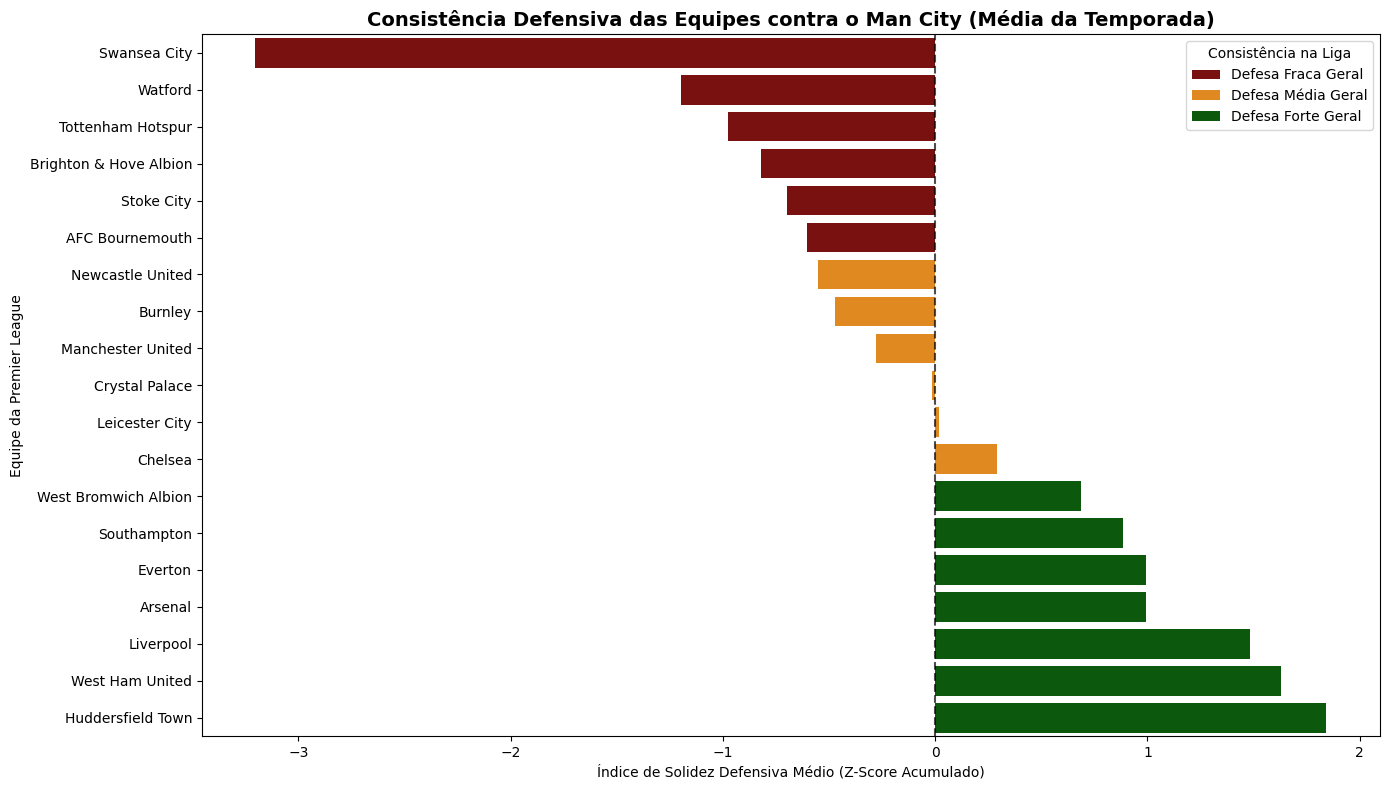

In [4]:
# ==============================================================================
# AGROPANDO OS DADOS POR TIME (MÉDIA DA TEMPORADA)
# ==============================================================================
# Agrupamos por adversário e calculamos a média das métricas e do score
df_times = df_defesa.groupby('Adversario', observed=False).agg(
    Score_Defensivo_Medio=('Score_Defensivo', 'mean'),
    Gols_Sofridos_Total=('Gols_Sofridos_Adversario', 'sum'), # Total nos 2 jogos
    xGA_Medio=('xGA_Acumulado_Adversario', 'mean')
).reset_index()

# Recriamos a classificação em tercis baseada na média consolidada
df_times['Classificacao_Equipe'] = pd.qcut(
    df_times['Score_Defensivo_Medio'], 
    q=3, 
    labels=['Defesa Fraca Geral', 'Defesa Média Geral', 'Defesa Forte Geral']
)

# Ordena os times do pior para o melhor score médio
df_times = df_times.sort_values(by='Score_Defensivo_Medio')

# ==============================================================================
# VISUALIZAÇÃO DA SOLIDEZ CONSOLIDADA POR TIME
# ==============================================================================
plt.figure(figsize=(14, 8))

sns.barplot(
    data=df_times, 
    x='Score_Defensivo_Medio', 
    y='Adversario', 
    hue='Classificacao_Equipe',
    palette={'Defesa Forte Geral': 'darkgreen', 'Defesa Média Geral': 'darkorange', 'Defesa Fraca Geral': 'darkred'},
    dodge=False
)

plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Consistência Defensiva das Equipes contra o Man City (Média da Temporada)', fontsize=14, weight='bold')
plt.xlabel('Índice de Solidez Defensiva Médio (Z-Score Acumulado)')
plt.ylabel('Equipe da Premier League')
plt.legend(title='Consistência na Liga')
plt.tight_layout()
plt.show()

In [5]:
# ==============================================================================
# 1. CONSTRUÇÃO DA TABELA DE INFORMAÇÕES POR TIME (CONSISTÊNCIA GERAL)
# ==============================================================================

# Dicionário auxiliar para mapear o placar de cada jogo na perspectiva do City
# (Útil para criarmos o Placar Agregado)
placar_jogos = {}
for _, match in df_matches[df_matches['wyId'].isin(df_defesa['matchId'])].iterrows():
    # Extrai o placar real da label do Wyscout (ex: "Brighton - Man City, 0 - 2")
    label_partida = match['label']
    try:
        placar_str = label_partida.split(',')[-1].strip() # Pega o "0 - 2"
        gols_time1 = int(placar_str.split('-')[0].strip())
        gols_time2 = int(placar_str.split('-')[1].strip())
        
        times_label = label_partida.split(',')[0]
        if "Manchester City" in times_label.split('-')[0]:
            # City jogou em casa -> Gols do City = gols_time1, Gols do rival = gols_time2
            placar_jogos[match['wyId']] = {'gols_city': gols_time1, 'gols_adv': gols_time2}
        else:
            # City jogou fora -> Gols do City = gols_time2, Gols do rival = gols_time1
            placar_jogos[match['wyId']] = {'gols_city': gols_time2, 'gols_adv': gols_time1}
    except:
        placar_jogos[match['wyId']] = {'gols_city': 0, 'gols_adv': 0}

# Função para gerar a string do placar agregado de cada time
def calcula_placar_agregado(match_ids):
    total_city = 0
    total_adv = 0
    for mid in match_ids:
        if mid in placar_jogos:
            total_city += placar_jogos[mid]['gols_city']
            total_adv += placar_jogos[mid]['gols_adv']
    return f"Man City {total_city} - {total_adv} Rival"

# Agrupando os dados por adversário
df_resumo_times = df_defesa.groupby('Adversario', observed=False).agg(
    Jogos_Enfrentados=('matchId', 'count'),
    Score_Defensivo_Medio=('Score_Defensivo', 'mean'),
    xGA_Medio_Sofrido=('xGA_Acumulado_Adversario', 'mean'),
    Total_Gols_Sofridos_Real=('Gols_Sofridos_Adversario', 'sum'),
    Distancia_Media_Chutes_Cedida=('Distancia_Media_Chutes_City', 'mean'),
    Intensidade_Pressao_PPDA=('PPDA_Adversario', 'mean'),
    Match_Ids_Lista=('matchId', lambda x: list(x))
).reset_index()

# Aplicando a classificação científica baseada nos tercis do Score Médio
df_resumo_times['Avaliacao_Defensiva'] = pd.qcut(
    df_resumo_times['Score_Defensivo_Medio'], 
    q=3, 
    labels=['Defesa Fraca', 'Defesa Média', 'Defesa Forte']
)

# Aplicando a função do placar agregado
df_resumo_times['Placar_Agregado_Temporada'] = df_resumo_times['Match_Ids_Lista'].apply(calcula_placar_agregado)

# Organizando e limpando as colunas para exibição do relatório
df_relatorio_final = df_resumo_times[[
    'Adversario', 
    'Avaliacao_Defensiva', 
    'Placar_Agregado_Temporada',
    'Total_Gols_Sofridos_Real', 
    'xGA_Medio_Sofrido', 
    'Intensidade_Pressao_PPDA',
    'Distancia_Media_Chutes_Cedida'
]].sort_values(by='xGA_Medio_Sofrido') # Ordenado do que cedeu menos perigo para o que cedeu mais

# Arredondando as colunas de ponto flutuante para ficar visualmente limpo
df_relatorio_final['xGA_Medio_Sofrido'] = df_relatorio_final['xGA_Medio_Sofrido'].round(2)
df_relatorio_final['Intensidade_Pressao_PPDA'] = df_relatorio_final['Intensidade_Pressao_PPDA'].round(2)
df_relatorio_final['Distancia_Media_Chutes_Cedida'] = df_relatorio_final['Distancia_Media_Chutes_Cedida'].round(2)

# Renomeando colunas para a exibição final
df_relatorio_final.columns = [
    'Adversário', 'Avaliação da Literatura', 'Placar Agregado',
    'Total de Gols Sofridos', 'Média de xGA Cedido', 'Média de PPDA (Pressão)',
    'Distância Média dos Chutes Cedida (m)'
]

# Exibindo a tabela formatada no Jupyter
print("==========================================================================================")
print("             RELATÓRIO CONSOLIDADO: EFICIÊNCIA DEFENSIVA NA PREMIER LEAGUE                ")
print("==========================================================================================")
show(df_relatorio_final, paging=False)

             RELATÓRIO CONSOLIDADO: EFICIÊNCIA DEFENSIVA NA PREMIER LEAGUE                


Loading ITables v2.8.0 from the internet... (need help?)


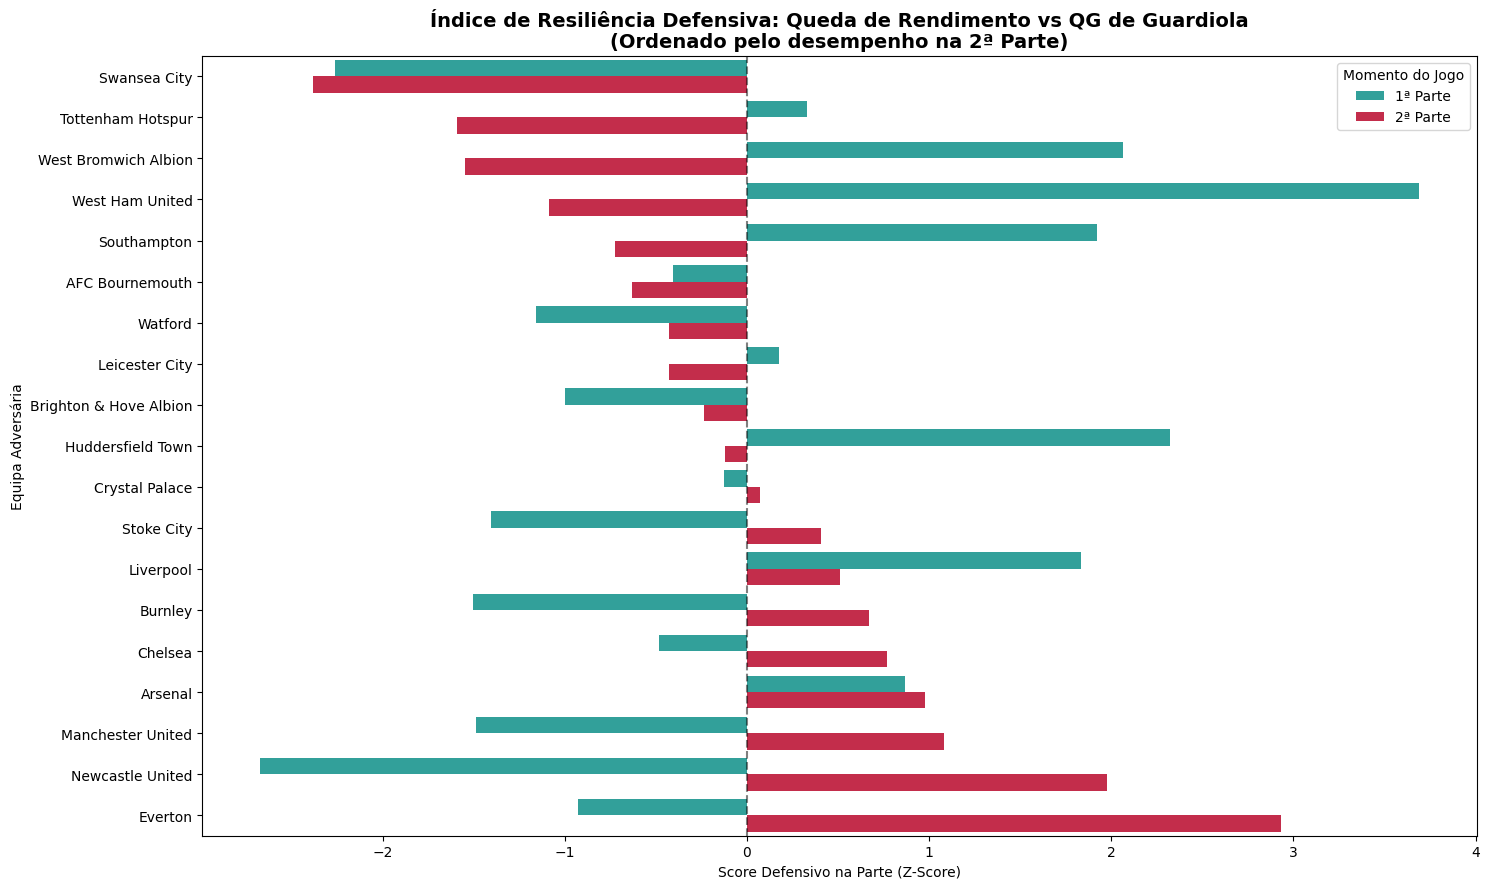

Parte,Adversario,1ª Parte,2ª Parte,Diferenca_Resiliencia,Diagnóstico de Resiliência
0,West Ham United,3.688902,-1.085737,-4.774639,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
1,West Bromwich Albion,2.063487,-1.548404,-3.611892,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
2,Southampton,1.920440,-0.725443,-2.645882,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
3,Huddersfield Town,2.322917,-0.122018,-2.444935,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
4,Tottenham Hotspur,0.331686,-1.593174,-1.924860,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
5,Liverpool,1.833080,0.513011,-1.320069,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
6,Leicester City,0.174238,-0.426099,-0.600337,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
7,AFC Bournemouth,-0.406600,-0.629090,-0.222491,🟡 Estável (Mantém o nível os 90m)
8,Swansea City,-2.261251,-2.382439,-0.121188,🟡 Estável (Mantém o nível os 90m)
9,Arsenal,0.866216,0.976149,0.109933,🟡 Estável (Mantém o nível os 90m)


In [6]:
# ==============================================================================
# 1. CÁLCULO DAS MÉTRICAS SEPARADO POR PARTE DO JOGO (1H vs 2H)
# ==============================================================================
dados_por_periodo = []

for m_id in df_defesa['matchId'].unique():
    # Recupera o nome do adversário já mapeado anteriormente
    nome_adv = df_defesa[df_defesa['matchId'] == m_id]['Adversario'].values[0]
    
    # Filtra os eventos daquela partida específica
    jogo_cru = df_events[df_events['matchId'] == m_id]
    jogo_df = extrai_coordenadas(jogo_cru)
    
    # Divide os eventos em Primeira Parte (1H) e Segunda Parte (2H)
    for periodo in ['1H', '2H']:
        df_periodo = jogo_df[jogo_df['matchPeriod'] == periodo]
        
        if len(df_periodo) == 0:
            continue
            
        # Recalcula as 3 métricas base do Score para aquela parte isolada
        # Métrica 1: xGA na parte
        chutes_city = df_periodo[(df_periodo['teamId'] == CITY_ID) & (df_periodo['eventName'] == 'Shot')].copy()
        if len(chutes_city) > 0:
            chutes_city['xg_estimado'] = chutes_city.apply(lambda r: 0.30 if (r['x'] > 84 and 25 < r['y'] < 75) else 0.05, axis=1)
            xGA = chutes_city['xg_estimado'].sum()
            dist_chute = np.sqrt((100 - chutes_city['x'])**2 + (50 - chutes_city['y'])**2).mean()
        else:
            xGA = 0.0
            dist_chute = np.nan
            
        # Métrica 2: Duelos na parte
        duelos_adv = df_periodo[(df_periodo['teamId'] != CITY_ID) & (df_periodo['eventName'] == 'Duel')].copy()
        if len(duelos_adv) > 0:
            duelos_adv['sucesso'] = duelos_adv['tags'].apply(lambda tags: 1 if isinstance(tags, list) and any(t.get('id') == 1801 for t in tags) else 0)
            pct_duelos = (duelos_adv['sucesso'].sum() / len(duelos_adv)) * 100
        else:
            pct_duelos = np.nan
            
        # Gols reais que o City marcou nesta parte
        gols_parte = chutes_city['tags'].apply(lambda tags: 1 if isinstance(tags, list) and any(t.get('id') == 101 for t in tags) else 0).sum()
        
        dados_por_periodo.append({
            'matchId': m_id,
            'Adversario': nome_adv,
            'Parte': '1ª Parte' if periodo == '1H' else '2ª Parte',
            'xGA': xGA,
            'Duelos_%': pct_duelos,
            'Distancia_Chutes': dist_chute,
            'Gols_Sofridos': gols_parte
        })

df_resiliencia_bruto = pd.DataFrame(dados_por_periodo)

# Preenche valores faltantes de distância com a média para não quebrar o Z-Score
df_resiliencia_bruto['Distancia_Chutes'] = df_resiliencia_bruto['Distancia_Chutes'].fillna(df_resiliencia_bruto['Distancia_Chutes'].mean())
df_resiliencia_bruto['Duelos_%'] = df_resiliencia_bruto['Duelos_%'].fillna(df_resiliencia_bruto['Duelos_%'].mean())

# ==============================================================================
# 2. NORMALIZAÇÃO POR Z-SCORE E CÁLCULO DO SCORE DE RESILIÊNCIA
# ==============================================================================
# Normalizamos considerando o universo de todas as partes jogadas
df_resiliencia_bruto['z_xGA'] = (df_resiliencia_bruto['xGA'] - df_resiliencia_bruto['xGA'].mean()) / df_resiliencia_bruto['xGA'].std()
df_resiliencia_bruto['z_Duelos'] = (df_resiliencia_bruto['Duelos_%'] - df_resiliencia_bruto['Duelos_%'].mean()) / df_resiliencia_bruto['Duelos_%'].std()
df_resiliencia_bruto['z_Distancia'] = (df_resiliencia_bruto['Distancia_Chutes'] - df_resiliencia_bruto['Distancia_Chutes'].mean()) / df_resiliencia_bruto['Distancia_Chutes'].std()

# Score Defensivo da Parte
df_resiliencia_bruto['Score_Parte'] = df_resiliencia_bruto['z_Duelos'] + df_resiliencia_bruto['z_Distancia'] - df_resiliencia_bruto['z_xGA']

# Agrupa por Time e por Parte para ter a média consolidada da temporada
df_resiliencia_times = df_resiliencia_bruto.groupby(['Adversario', 'Parte'], observed=False)['Score_Parte'].mean().reset_index()

# ==============================================================================
# 3. VISUALIZAÇÃO GRÁFICA DE SINALIZADOR (SLOPING PLOT / BAR COMPLEMENTAR)
# ==============================================================================
plt.figure(figsize=(15, 9))

# Ordenar a visualização com base na resiliência (quem teve a melhor 2ª parte)
ordem_times = df_resiliencia_times[df_resiliencia_times['Parte'] == '2ª Parte'].sort_values(by='Score_Parte')['Adversario'].tolist()

sns.barplot(
    data=df_resiliencia_times, 
    x='Score_Parte', 
    y='Adversario', 
    hue='Parte', 
    order=ordem_times,
    palette={'1ª Parte': 'lightseagreen', '2ª Parte': 'crimson'}
)

plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Índice de Resiliência Defensiva: Queda de Rendimento vs QG de Guardiola\n(Ordenado pelo desempenho na 2ª Parte)', fontsize=14, weight='bold')
plt.xlabel('Score Defensivo na Parte (Z-Score)')
plt.ylabel('Equipa Adversária')
plt.legend(title='Momento do Jogo')
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. EXIBIÇÃO DA TABELA DE DIAGNÓSTICO DE QUEBRA FÍSICA/TÁTICA
# ==============================================================================
df_pivot = df_resiliencia_times.pivot(index='Adversario', columns='Parte', values='Score_Parte').reset_index()
df_pivot['Diferenca_Resiliencia'] = df_pivot['2ª Parte'] - df_pivot['1ª Parte']

# Classifica o comportamento da equipa
def avalia_resiliencia(linha):
    if linha['Diferenca_Resiliencia'] < -0.5:
        return '🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)'
    elif linha['Diferenca_Resiliencia'] > 0.5:
        return '🟢 Ajuste Tático / Crescimento Defensivo'
    else:
        return '🟡 Estável (Mantém o nível os 90m)'

df_pivot['Diagnóstico de Resiliência'] = df_pivot.apply(avalia_resiliencia, axis=1)
display(df_pivot.sort_values(by='Diferenca_Resiliencia').reset_index(drop=True))